# Lab Task 2: Opening and Closing

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Image

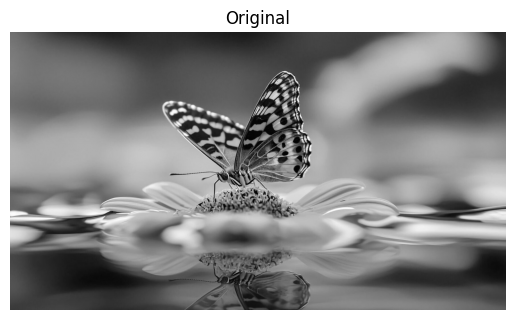

In [2]:
img = cv2.imread('../CVLab02/assets/buter.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off'); plt.show()

## Opening (Erosion → Dilation)

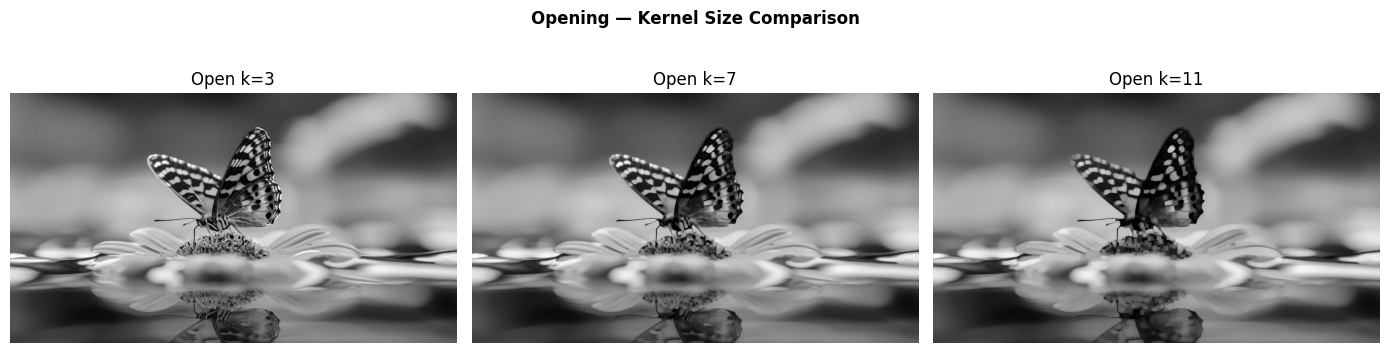

In [3]:
# Opening = Erosion followed by Dilation
# Removes small white noise (bright specs) outside objects

k3  = np.ones((3, 3), np.uint8)
k7  = np.ones((7, 7), np.uint8)
k11 = np.ones((11, 11), np.uint8)

open_3  = cv2.morphologyEx(img, cv2.MORPH_OPEN, k3)
open_7  = cv2.morphologyEx(img, cv2.MORPH_OPEN, k7)
open_11 = cv2.morphologyEx(img, cv2.MORPH_OPEN, k11)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Opening — Kernel Size Comparison', fontweight='bold')
for ax, res, k in zip(axes, [open_3, open_7, open_11], [3, 7, 11]):
    ax.imshow(res, cmap='gray'); ax.set_title(f'Open k={k}'); ax.axis('off')
plt.tight_layout(); plt.show()

## Closing (Dilation → Erosion)

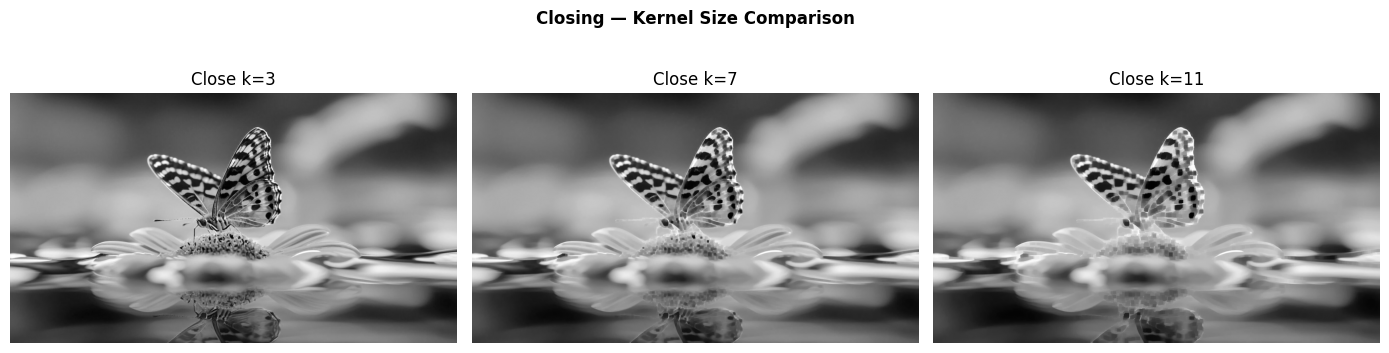

In [4]:
# Closing = Dilation followed by Erosion
# Fills small dark holes/gaps inside objects

close_3  = cv2.morphologyEx(img, cv2.MORPH_CLOSE, k3)
close_7  = cv2.morphologyEx(img, cv2.MORPH_CLOSE, k7)
close_11 = cv2.morphologyEx(img, cv2.MORPH_CLOSE, k11)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Closing — Kernel Size Comparison', fontweight='bold')
for ax, res, k in zip(axes, [close_3, close_7, close_11], [3, 7, 11]):
    ax.imshow(res, cmap='gray'); ax.set_title(f'Close k={k}'); ax.axis('off')
plt.tight_layout(); plt.show()

## Different Structuring Elements

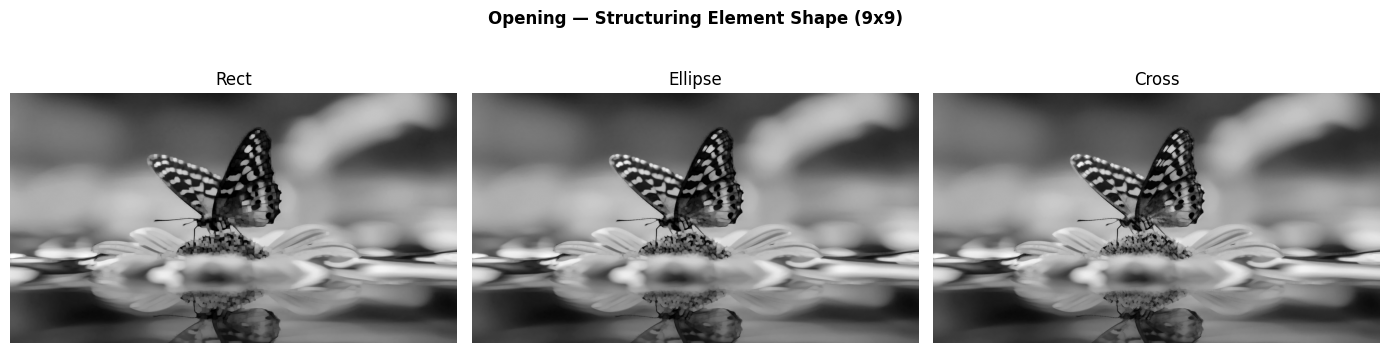

In [5]:
# Structuring element shape changes which features are affected
rect  = cv2.getStructuringElement(cv2.MORPH_RECT,    (9, 9))
ellip = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
cross = cv2.getStructuringElement(cv2.MORPH_CROSS,   (9, 9))

open_rect  = cv2.morphologyEx(img, cv2.MORPH_OPEN, rect)
open_ellip = cv2.morphologyEx(img, cv2.MORPH_OPEN, ellip)
open_cross = cv2.morphologyEx(img, cv2.MORPH_OPEN, cross)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Opening — Structuring Element Shape (9x9)', fontweight='bold')
for ax, res, t in zip(axes, [open_rect, open_ellip, open_cross], ['Rect', 'Ellipse', 'Cross']):
    ax.imshow(res, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

## Side-by-Side Comparison

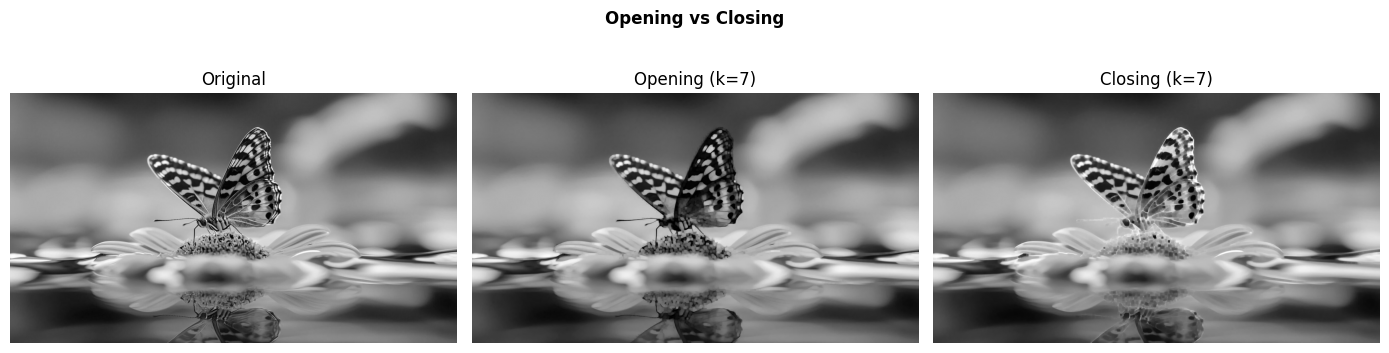

Opening : Erosion then Dilation  → removes small bright spots outside objects
Closing : Dilation then Erosion  → fills small dark holes inside objects
Larger kernel = more aggressive removal/filling


In [6]:
imgs   = [img, open_7, close_7]
labels = ['Original', 'Opening (k=7)', 'Closing (k=7)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Opening vs Closing', fontweight='bold')
for ax, im, lbl in zip(axes, imgs, labels):
    ax.imshow(im, cmap='gray'); ax.set_title(lbl); ax.axis('off')
plt.tight_layout(); plt.show()

print('Opening : Erosion then Dilation  → removes small bright spots outside objects')
print('Closing : Dilation then Erosion  → fills small dark holes inside objects')
print('Larger kernel = more aggressive removal/filling')